<a href="https://colab.research.google.com/github/FatemehNMT/Visual-SLAM-from-Scratch-Google-Colab/blob/main/Learning_Visual_SLAM_Google_Colab_Part_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Summery: Main Concepts**

1. **Lie Group & Lie Algebra**  
   Mathematical tools for representing and computing 3D camera motion and pose, mainly using `SE(3)` and `SO(3)`.

2. **Ceres and g2o**  
   Libraries for solving nonlinear optimization problems. Ceres is more general-purpose, while g2o is widely used for graph-based optimization in SLAM.

3. **Bundle Adjustment (BA)**  
   Joint optimization of camera poses and 3D map points by minimizing the reprojection error.

4. **Epipolar Geometry**  
   The geometric relationship between two images of the same scene, which constrains the location of corresponding points.

5. **PnP (Perspective-n-Point)**  
   Estimates the camera pose from known 3D points and their corresponding 2D image points.

6. **Visual Odometry (VO)**  
   Estimates the camera motion between consecutive frames using visual features from images.

7. **Solve a BA Problem with g2o**  
   Builds a graph of camera poses and landmarks and optimizes them using g2o to reduce reprojection error.

8. **Pose Graph Optimization with g2o**  
   Optimizes camera or keyframe poses using constraints between them; commonly used in loop closure and global optimization.

9. **Map-based Localization**  
   Estimates the current camera pose inside a previously built map, without necessarily creating a new map.

In [ ]:
Raw Image
    │
    ▼
Feature Detection
    │
    ▼
Feature Matching
    │
    ▼
P3P ─────────────► g2o
    │
    ▼
Pose Estimation
    │
    ▼
Bundle Adjustment ─────► Sophus
    │
    ▼
Map

**Overall SLAM Cycle**

In practice, SLAM repeatedly moves through a cycle like this:

**Feature Tracking → Pose Estimation (PnP) → Map Update (Triangulation) → Optimization (BA)**

However, during the **initialization stage**, reliable 3D map points may not yet be available. Since PnP requires known **3D landmarks and their corresponding 2D image points**, it generally cannot be used at this stage.

Instead, **Visual Odometry (VO) based on epipolar geometry** is used to estimate the initial relative motion of the camera between the first frames. This initial motion estimate helps initialize the camera poses and build the first 3D landmarks.

Once a sufficient and reliable map has been created, the system can use PnP to estimate the pose of each new frame from **3D–2D correspondences**.

So the process can be viewed as:

**Initialization:**  
**Feature Matching → Visual Odometry → Initial Pose → Triangulation → Initial Map**

**After Initialization:**  
**Feature Tracking → PnP Pose Estimation → Map Update → Bundle Adjustment**

This is also where libraries such as **g2o** and tools such as **Sophus** become useful:

- **g2o** is commonly used to formulate and solve graph-based nonlinear optimization problems such as BA and pose graph optimization.
- **Sophus** is commonly used to represent and update camera poses on Lie groups such as `SO(3)` and `SE(3)`, which is especially useful during optimization.

**VO = process**  
**Epipolar Geometry = method/tool used inside that process**

So:

**Initialization:**

**Feature Matching → Epipolar Geometry (Essential Matrix) → Relative Pose Estimation → Triangulation → Initial Map**

## **Initialization**

At the beginning of SLAM, we do not yet have reliable **3D map points**, so we cannot use PnP directly.

We first perform **Feature Detection & Matching** between two frames.

Then, using **Epipolar Geometry**, we estimate the relative motion between the two camera poses.

## **Epipolar Geometry**

Epipolar Geometry describes the geometric relationship between two views of the same scene.

If a point is observed in the first image, its corresponding point in the second image cannot appear anywhere randomly. It must lie on a specific **epipolar line**.

Using matched feature points, we can estimate the **Essential Matrix** and recover the relative camera motion:

- **R → relative rotation**
- **t → relative translation direction**

> In a monocular system, the absolute scale of translation cannot be determined from two images alone.

## **Stereo Initialization**

In a stereo SLAM system, the relative pose between the left and right cameras is already known from camera calibration.

Therefore, after detecting and matching features between the left and right images, we can estimate depth directly from the stereo geometry.

Using this depth, we can reconstruct the initial **3D landmarks / MapPoints** immediately.

Because the stereo baseline is known, stereo SLAM can recover the **metric scale** of the scene from the beginning.

So the stereo initialization pipeline can be written as:

**Left & Right Images → Feature Detection & Matching → Stereo Triangulation / Depth Estimation → Initial 3D Map**

After the initial 3D MapPoints are available, the pose of the following frames can be estimated using:

**3D MapPoints + 2D Feature Observations → PnP → Camera Pose**

## **Monocular vs Stereo Initialization**

**Monocular:**

**Feature Matching → Epipolar Geometry → Relative Pose → Triangulation → Initial Map**

- Translation is initially recovered only **up to scale**.

**Stereo:**

**Stereo Feature Matching → Depth / Triangulation → Initial 3D Map**

- The known stereo baseline provides **metric scale** from the beginning.

## **Triangulation**

Once we know the relative camera poses and have corresponding 2D feature points in both images, we can use **Triangulation** to estimate their 3D positions.

These reconstructed 3D points become the first **landmarks / MapPoints** of the map.

## **After Initialization**

Once the map contains reliable 3D landmarks, we can use **PnP (Perspective-n-Point)** for new frames.

PnP uses:

**Known 3D MapPoints + Corresponding 2D Feature Points → Current Camera Pose**

After that, new points can be triangulated and the whole system can be refined using **Bundle Adjustment (BA)**.

**Normal SLAM cycle:**

**Feature Tracking → PnP Pose Estimation → Map Update / Triangulation → Bundle Adjustment**

# **Useful Diagrams**

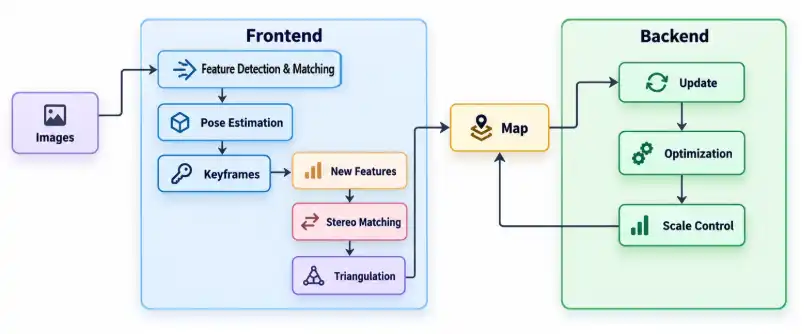

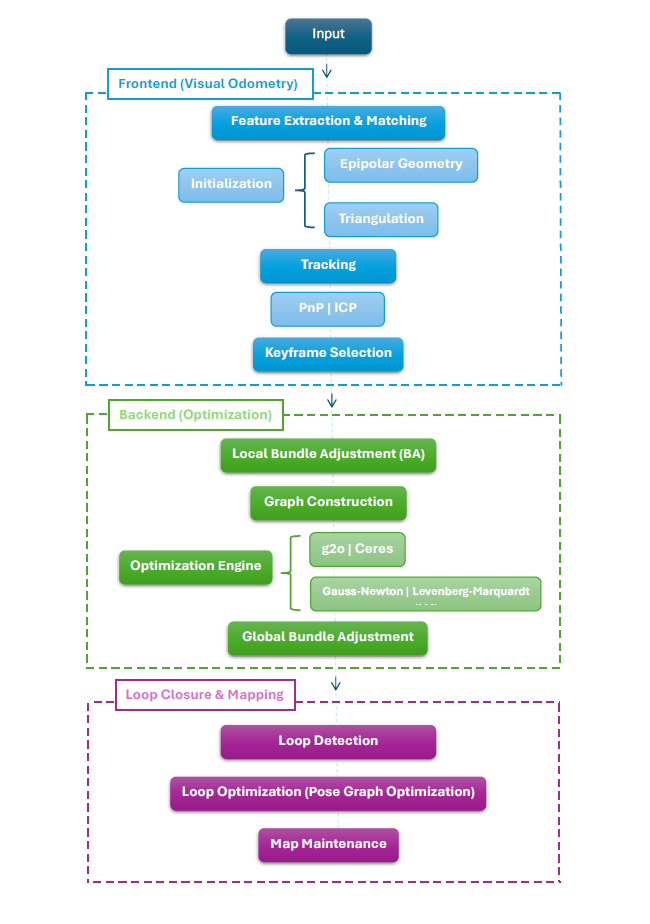

In [ ]:
Dataset
   ↓
Frame
   ↓
Feature Extraction
   ↓
Feature Matching
   ↓
Pose Estimation
   ↓
Mapping

In [ ]:
Triangulation
   ↓
Local Map (KeyFrame Structure)
   ↓
Pose Tracking (PnP + BA)

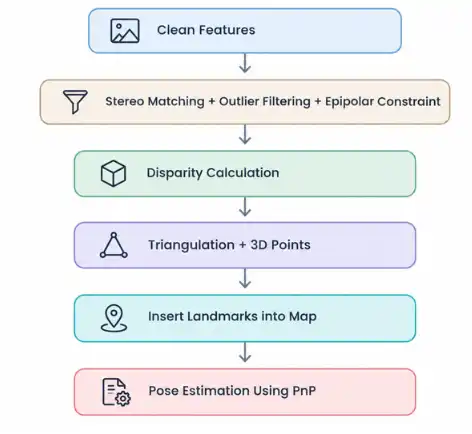

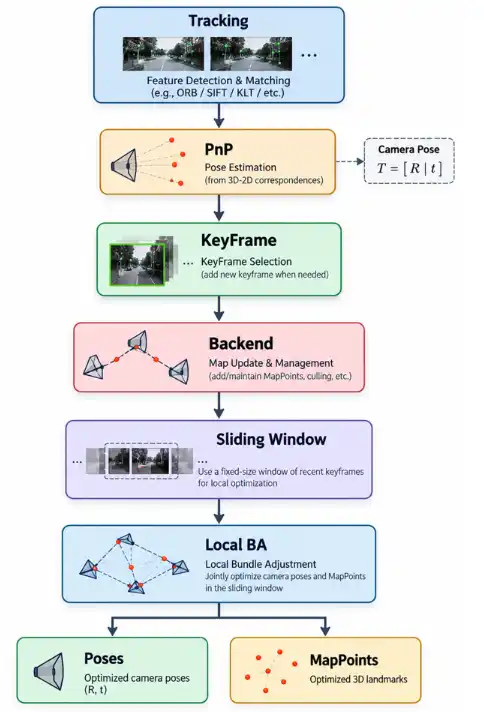

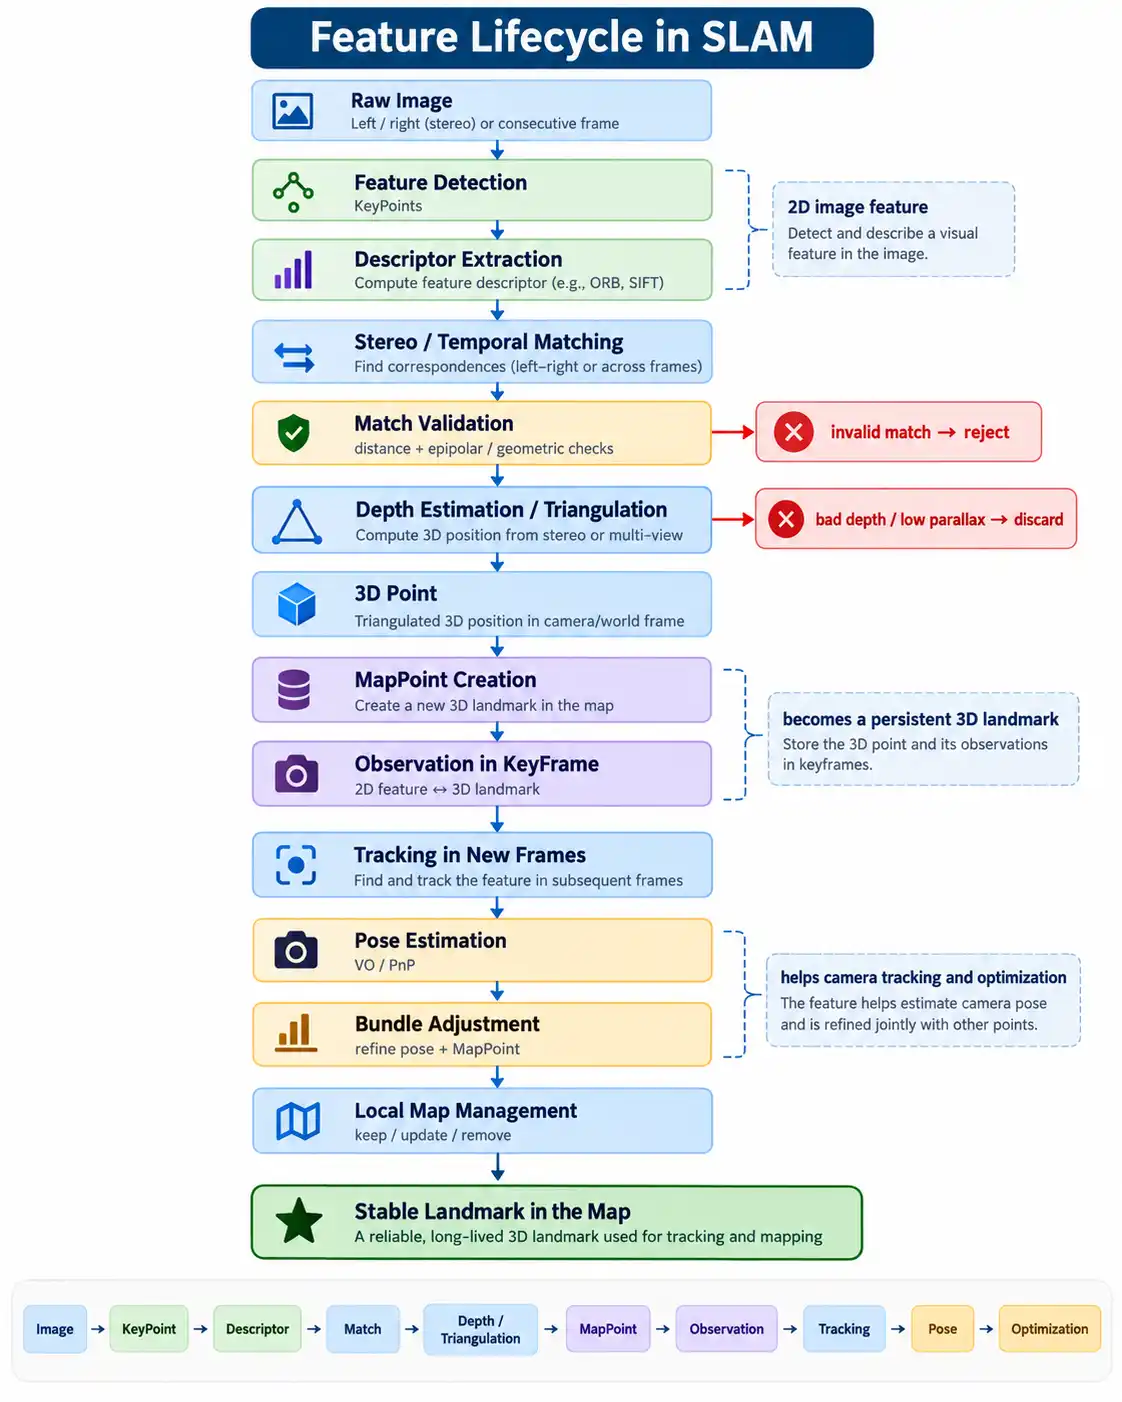

# **SLAM Structure Designe**

**Four Main Files**

| File | Role |
|---|---|
| `Frame.h` | Stores keypoints, matches, pose, and depth information. |
| `MapPoint.h` | Represents a 3D point in the map along with its observations. |
| `Keyframe.h` | Stores selected stable frames used as keyframes in the map. |
| `Map.h` | Maintains and manages keyframes and map points. |

In [ ]:
Map
│
├── KeyFrames
│     ├── Frame 1
│     │     └── KeyPoints / features
│     ├── Frame 2
│     │     └── KeyPoints / features
│     └── Frame 3
│           └── KeyPoints / features
│
└── MapPoints
      ├── P1
      ├── P2
      └── P3

In [ ]:
KeyFrame 1
   │
   ├── KeyPoint 17 ─────┐
   │                    │
   ├── KeyPoint 25 ──┐  │
   │                 │  │
   └── KeyPoint 42 ──┼──┼──→ MapPoint
                     │  │
KeyFrame 2           │  │
   │                 │  │
   └── KeyPoint 8 ───┘  │
                        │
KeyFrame 3              │
   │                    │
   └── KeyPoint 13 ─────┘

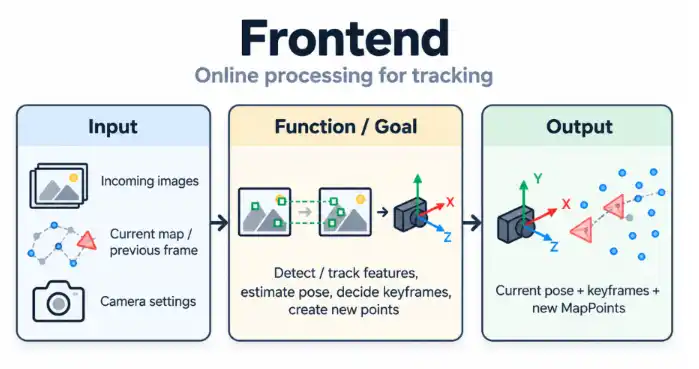

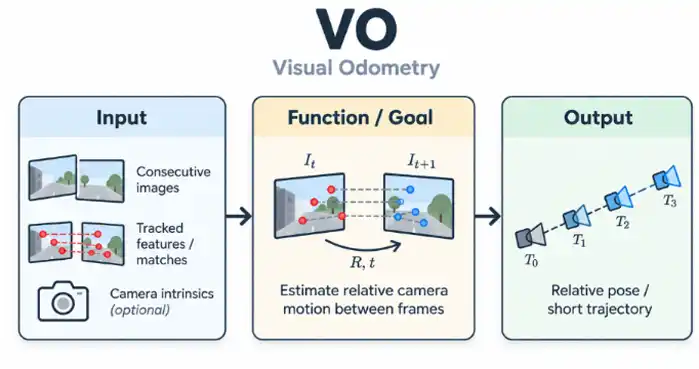

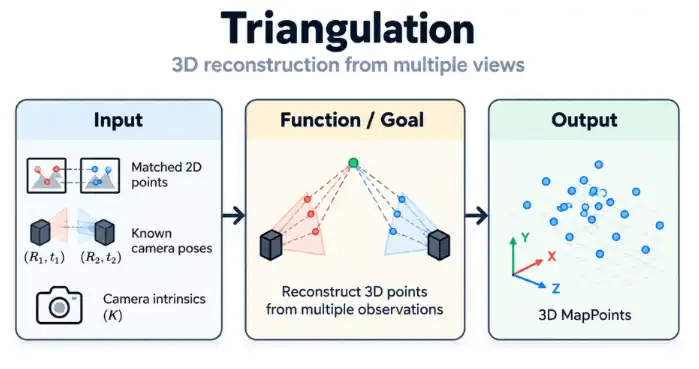

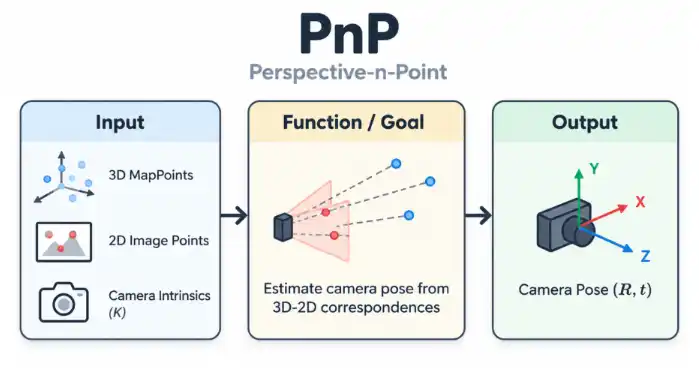

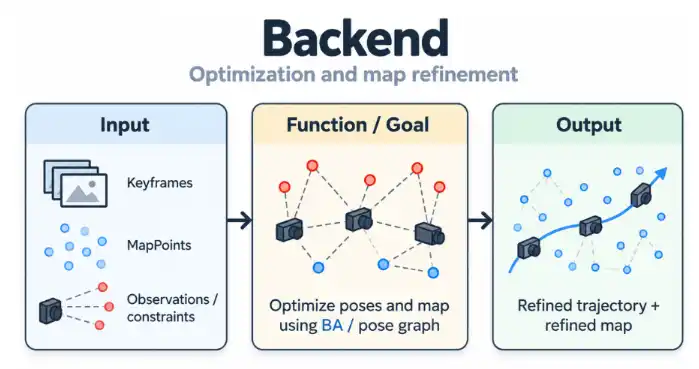

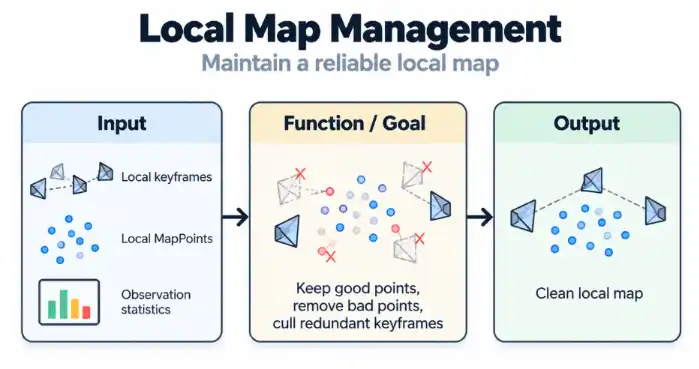

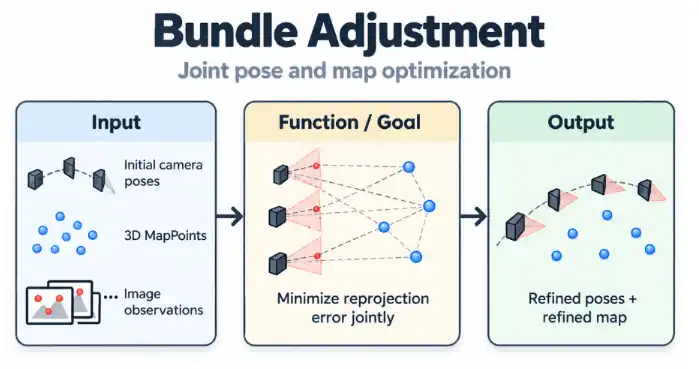

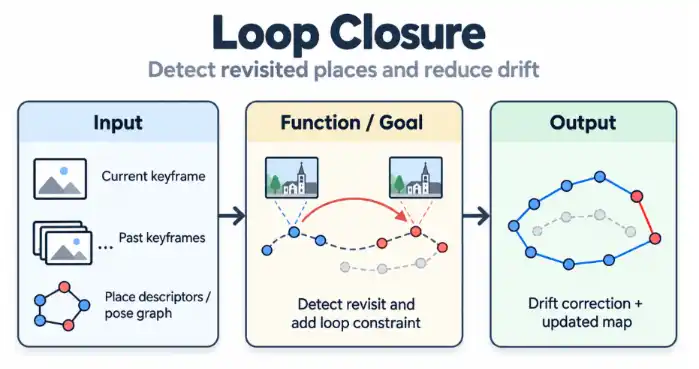

## **Is This a Circular Dependency?**

A common question is:

> **“If the camera Pose is estimated from MapPoints, and the MapPoints themselves are created using camera Poses, isn’t this a circular dependency?”**

The answer is **no**, because each step uses different information:

- **MapPoints** are created through **Triangulation** using observations from multiple camera views.
- **PnP** uses existing **MapPoints + new 2D observations** to estimate the camera **Pose**.
- **Bundle Adjustment (BA)** then jointly refines both the camera poses and the MapPoints.

So, although camera poses and MapPoints depend on each other, they are not estimated from exactly the same information at the same step.

This distinction is very important and is one of the fundamental ideas for understanding how **SLAM** works.

---

# **Which Points Build the Map?**

In our stereo SLAM pipeline, MapPoints are created through the following process:

1. Features are matched between the **left and right images**.
2. **Disparity** is computed, and from it the **depth** of each matched point is estimated.
3. Valid observations are reconstructed as **3D points**.
4. These valid 3D points are converted into **MapPoints**.
5. The MapPoints are associated with the corresponding **KeyFrame** and inserted into the map.

So the pipeline can be summarized as:

**Left–Right Feature Matching → Disparity → Depth → 3D Reconstruction → MapPoint → Map**

### **Which 3D Points Become MapPoints?**

Not every detected feature becomes part of the map.

A point should satisfy geometric and matching validity conditions, such as:

- It is successfully observed and matched in both stereo images.
- It has a valid disparity.
- Its estimated depth is positive and within a reasonable range.
- Its stereo geometry / parallax is sufficient for reliable 3D reconstruction.

If these conditions are satisfied, the reconstructed 3D point can become a **MapPoint**.

If a feature:

- is visible only in one image,
- has an unreliable stereo match,
- produces invalid or unstable depth,
- or fails the geometric checks,

it should **not** be inserted into the map.

### **KeyFrames and MapPoint Creation**

In our current design, new MapPoints are mainly created when a **KeyFrame** is inserted.

This means:

- KeyFrames provide important observations used to expand the map.
- Valid stereo points from a KeyFrame can become new MapPoints.
- Ordinary frames are mainly used for tracking and pose estimation and do not necessarily create new landmarks.

So the important distinction is:

**Feature ≠ MapPoint**

A **Feature / KeyPoint** is a 2D observation in an image, while a **MapPoint** is a validated 3D landmark stored in the map.

---

# **Frontend**

In our current SLAM system, a major role of the **Frontend** is to perform **Visual Odometry (VO)** and process incoming images in real time.

**Visual Odometry** estimates the motion of the camera from a sequence of images.

In the KITTI dataset, the camera setup is stereo. In our current implementation:

**Left → Left images across time** are mainly used for tracking and relative motion estimation.

**Left ↔ Right images at the same timestamp** are used for stereo matching and depth estimation.

## **Main Goal of the Frontend**

The Frontend provides a **fast, online estimate of the camera pose** and creates or updates the initial/local map information needed for tracking.

The process is approximately:

1. **Feature Extraction**  
   Extract keypoints and descriptors from the images, for example using ORB.

2. **Stereo Depth / Triangulation**  
   Match features between the left and right images.  
   Using stereo disparity and the known camera calibration, estimate depth and reconstruct 3D points.

   **Left + Right → Stereo Matching → Depth → 3D MapPoints**

3. **Camera Motion Estimation**  
   Match features between consecutive left images:

   \[
   I_t^{left} \leftrightarrow I_{t+1}^{left}
   \]

   Using these correspondences:

   **Feature Matches → Essential Matrix → `recoverPose()` → Relative (R,t)**

   This estimates the relative motion of the camera between two consecutive frames.

4. **Trajectory Update**  
   The relative motion is composed with the previous camera pose to obtain the new pose and extend the estimated trajectory.

   Conceptually:

   \[
   T_{new}=T_{previous}\cdot T_{relative}
   \]

   The exact multiplication order depends on whether the system uses `Tcw`, `Twc`, or another pose convention.

5. **Map and KeyFrame Update**  
   New valid MapPoints and selected KeyFrames are added when necessary, allowing the initial/local map to grow.

So, in simple terms:

> **Frontend = fast frame-by-frame tracking, pose estimation, and local map creation/update.**

## **Important Note About `recoverPose()`**

When `recoverPose()` is used only with two monocular images, it recovers:

- Rotation (R)
- Translation direction (t)

but not the absolute translation scale.

Because our system is stereo, metric depth information can later be used to recover scale more reliably. A 3D–2D method such as **PnP** can also provide metric pose estimates once reliable MapPoints are available.

---

# **Backend**

The **Backend** takes the estimates produced by the Frontend and improves their consistency and accuracy.

Instead of looking only at the current frame, it considers a larger set of information, such as:

**Camera Poses + MapPoints + Observations / Constraints**

These are represented as an optimization problem, often as a graph.

The Backend jointly refines these variables so that the observations agree as well as possible with the estimated camera poses and 3D structure.

Its goals include:

- reducing accumulated drift,
- refining camera poses,
- refining MapPoint positions,
- reducing reprojection error,
- improving map consistency,
- and producing a smoother and more accurate trajectory.

One of the most important Backend optimization processes is **Bundle Adjustment (BA)**:

**Camera Poses + MapPoints → Minimize Reprojection Error → Refined Poses + Refined Map**

Depending on the SLAM architecture, the Backend may perform **Local BA**, global optimization, pose graph optimization, and other map-refinement operations.

So, in simple terms:

> **Frontend = fast estimation**  
> **Backend = accurate optimization**

A useful mental model is:

> **Frontend = Reflex**  
> **Backend = Brain**

The Frontend reacts quickly to incoming images and produces an approximate current state, while the Backend uses more observations and more computation to improve that state.

## **Overall Relationship**

The system first obtains approximate motion and map information from the Frontend:

**Images → Frontend → Estimated Poses + MapPoints + KeyFrames**

Then the Backend improves them:

**Estimated Poses + MapPoints + Observations → Backend Optimization → Refined Trajectory + Refined Map**

So yes: the camera poses produced during tracking are initially **estimates**, but they are not the only information available. The system also maintains **MapPoints and image observations**, and the Backend uses all of them together to improve the SLAM solution.

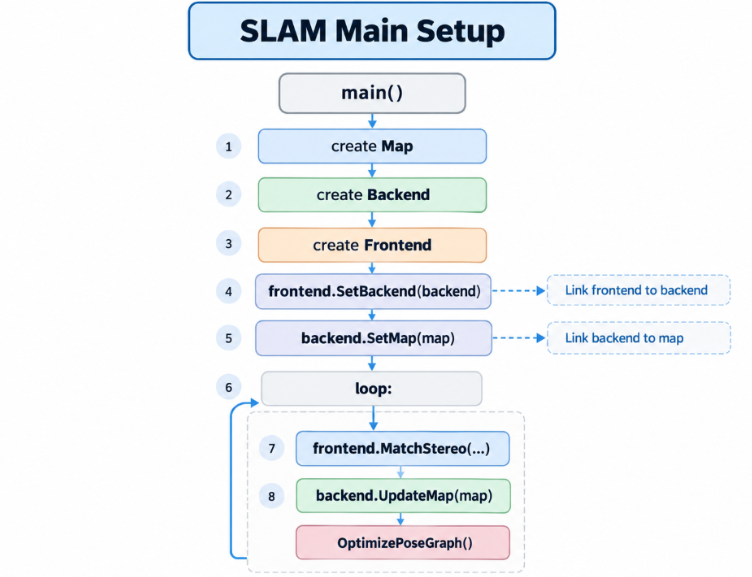

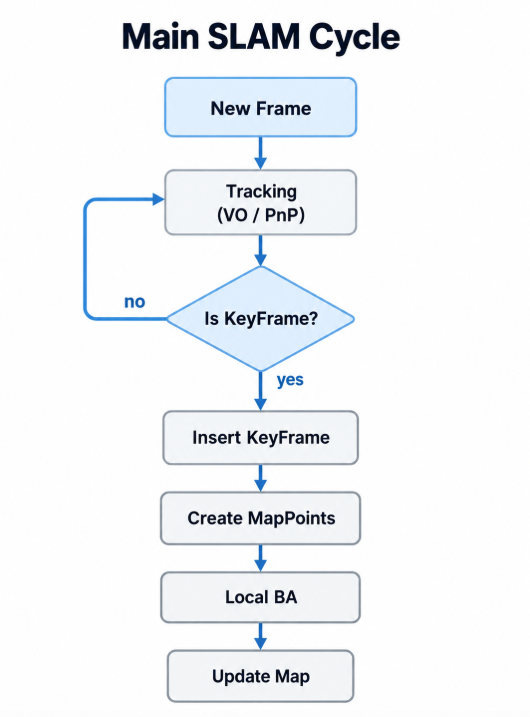

# **Measurement Model = Graph Structure**

The camera is only the **sensor** that produces measurements.

How those measurements enter the optimization problem is defined by the **Edge**.

This is an important idea in graph-based SLAM:

> **The Edge defines the mathematical relationship between the variables in the optimization problem.**

If we replace:

```cpp
g2o::EdgeProjectXYZ2UV
```

with another type of edge, the mathematical structure of the optimization problem changes.

## **What Does an Edge Define?**

An Edge determines:

- which variables / vertices are connected,
- how the residual error is computed,
- how the Jacobians are formed,
- and consequently how the Hessian structure is built.

So, conceptually:

> **Edge = Mathematical definition of a measurement constraint**

---

# **Our Current Edge**

We currently use:

```cpp
g2o::EdgeProjectXYZ2UV
```

Conceptually, this represents:

**3D Point + SE(3) Camera Pose → Projection → 2D Image Point**

Therefore, the graph contains:

```text
VertexSE3Expmap      → Camera Pose
VertexPointXYZ       → 3D Landmark
EdgeProjectXYZ2UV    → 2D Reprojection Error
```

The residual compares:

\[
\text{Observed 2D pixel}
\]

with:

\[
\text{Projected 3D MapPoint}
\]

So this corresponds to the standard **monocular reprojection model used in Bundle Adjustment**.

---

# **What Happens If We Change the Edge?**

For example, if we use a **Stereo Edge**, conceptually similar to:

```cpp
EdgeProjectXYZ2UVStereo
```

the measurement may contain:

\[
(u_L, v_L, d)
\]

where:

- \(u_L\) = horizontal coordinate in the left image
- \(v_L\) = vertical coordinate in the left image
- \(d\) = stereo disparity

Instead of a 2D residual, we now have a **3D residual**.

So:

## **Monocular Measurement**

\[
e =
\begin{bmatrix}
e_u \\
e_v
\end{bmatrix}
\]

## **Stereo Measurement**

\[
e =
\begin{bmatrix}
e_u \\
e_v \\
e_d
\end{bmatrix}
\]

As a result:

- the **Information Matrix** changes,
- the Jacobian dimensions change,
- the Hessian structure also changes,
- the stereo measurement provides an additional depth / scale constraint,
- and the optimization may become better constrained in scale compared with a purely monocular formulation.

This is the general idea used by stereo SLAM systems when stereo reprojection constraints are included in optimization.

---

# **A Deeper View of the Edge**

The selected Edge influences important properties of the optimization problem, including:

- **Residual dimension**
- **Jacobian structure**
- **Sparsity pattern**
- **Hessian structure**
- **Conditioning**
- **Convergence behavior**

So the measurement model represented by the Edge has a major effect on the structure and numerical behavior of the SLAM optimization.

A small correction to keep this precise:

> The Edge strongly influences the optimization structure, but it does **not by itself determine the entire SLAM architecture** or whether a sliding window must be used.

Sliding-window optimization is mainly a system-design decision related to computational cost and local optimization size.

---

# **The Solver Framework Does Not Necessarily Change**

Even if the Edge type changes, the general optimization objective is still typically:

\[
\min_{\mathbf{x}} \sum_i e_i^T \Omega_i e_i
\]

where:

- \(e_i\) = residual error of measurement \(i\)
- \(\Omega_i\) = Information Matrix
- \(\mathbf{x}\) = optimization variables such as poses and landmarks

The problem can still be solved using methods such as:

- **Gauss–Newton**
- **Levenberg–Marquardt**

So:

> **Changing the Edge changes the measurement model and the internal structure of the optimization problem, while the overall nonlinear least-squares solver framework can remain the same.**

# **SLAM Essentials Map — Part I**

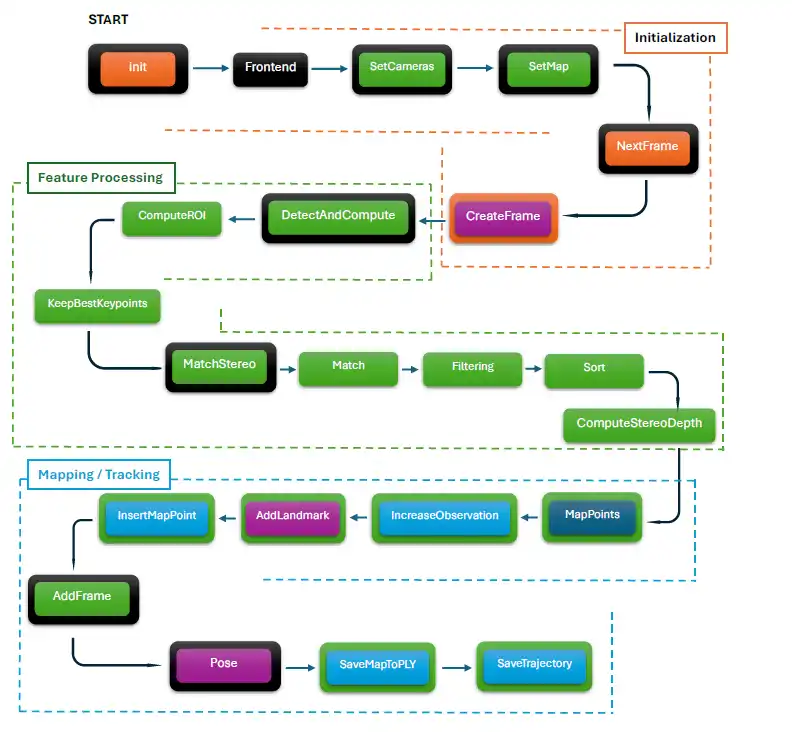

**SLAM Frontend & Initialization Flow _ Part I**:\
This flowchart uses colors to represent different parts of the codebase.
The **background color** indicates where each function or module is *declared*, while the **foreground color** shows where it is used or *called* in the pipeline.\
Dashed boundaries divide the SLAM system into its major stages: **Initialization**, **Feature Processing**, and **Mapping / Tracking**.

A short **summery** of what we have done up to here is presented in the following.

In [ ]:
main → Dataset.Init
     → load frames
     → Frontend.AddFrame
          → detect
          → match
          → depth
          → triangulate
          → map insert
     → save map & trajectory


**Start:**

In [ ]:
main()

**Input:**

In [ ]:
dataset_path = argv[1]

**Dataset Preparation:**

In [ ]:
Dataset::Ptr ds(new Dataset(dataset_path));

**Init()**

In [ ]:
ds->Init()
    ├─ Check document of image_0
    ├─ Check document of image_1
    ├─ Save pathes
    └─ Date preparation for reading frames

**Frontend**

In [ ]:
Frontend::Ptr frontend(new Frontend(...));
frontend->SetCameras(cam_left, cam_right);
frontend->SetMap(map);

**Main Loop**

In [ ]:
for frame_id in frames:
    Frame::Ptr frame(new Frame());
    ds->NextFrame(frame);  // Loading L and R images
    frontend->AddFrame(frame);

**Frontend::AddFrame()**

In [ ]:
AddFrame(frame):
    ├─ DetectAndCompute(frame)
    │      ├─ ROI
    │      ├─ ORB detect
    │      ├─ ORB descriptors
    │      └─ Best keypoints
    │
    ├─ MatchStereo(frame, matches)
    │      ├─ BFMatcher raw match
    │      ├─ epipolar filtering
    │      ├─ sort by distance
    │      └─ resize to N matches
    │
    ├─ ComputeStereoDepth()
    │      ├─ disparity = xL - xR
    │      ├─ Z = fx * B / disp
    │      ├─ X = (u - cx) * Z / fx
    │      └─ Y = (v - cy) * Z / fy
    │
    ├─ Generate MapPoint for each point
    │      ├─ mp = new MapPoint()
    │      ├─ mp->IncreaseObservation()
    │      ├─ frame->AddLandmark(mp)
    │      └─ map_->InsertMapPoint(mp)
    │
    └─ map_->InsertKeyFrame(frame)


**Track**

In [ ]:
Track(new_frame):
    ├─ match new_frame with last_frame
    ├─ findEssentialMat()
    ├─ recoverPose()
    ├─ SE3 concatenation
    ├─ last_frame = new_frame
    └─ return success


**Map**

In [ ]:
InsertKeyFrame(frame):
    keyframes_[id] = frame

InsertMapPoint(mp):
    map_points_[id] = mp

AddFrame(frame):
    all_frames_.push_back(frame)


**Save Results**

In [ ]:
Map::SaveMapToPLY("map_xxx.ply")
Map::SaveTrajectory("trajectory.txt")
main.cpp → directly saving trajectory from all_frames_
